<a href="https://colab.research.google.com/github/TunaStark/ITO-ML-DL-Examples/blob/master/Machine_Learning/ITO_ML_Examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')

print(f"Veri Seti Boyutu: {df.shape}")

df.head()

Veri Seti Boyutu: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Sadece eksik verisi olanları sıralıyoruz.
eksik_veriler = df.isnull().sum()
eksik_veriler = eksik_veriler[eksik_veriler > 0].sort_values(ascending=False)

# Kaç tane sütun verisi eksik
print(f"Toplam {len(eksik_veriler)} sütunda eksik veri var.\n")

# Yüzdelik eksik
eksik_yuzde = (eksik_veriler / len(df)) * 100
eksik_tablo = pd.DataFrame({'Eksik Veri Sayısı': eksik_veriler, 'Yüzde (%)': eksik_yuzde.round(2)})

print(eksik_tablo)

Toplam 19 sütunda eksik veri var.

              Eksik Veri Sayısı  Yüzde (%)
PoolQC                     1453      99.52
MiscFeature                1406      96.30
Alley                      1369      93.77
Fence                      1179      80.75
MasVnrType                  872      59.73
FireplaceQu                 690      47.26
LotFrontage                 259      17.74
GarageType                   81       5.55
GarageYrBlt                  81       5.55
GarageFinish                 81       5.55
GarageQual                   81       5.55
GarageCond                   81       5.55
BsmtExposure                 38       2.60
BsmtFinType2                 38       2.60
BsmtQual                     37       2.53
BsmtCond                     37       2.53
BsmtFinType1                 37       2.53
MasVnrArea                    8       0.55
Electrical                    1       0.07


In [ ]:
# yok olarak doldurulacak sütunlar
garaj_kat = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
bodrum_kat = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
diger_kat = ['MasVnrType']

for col in garaj_kat + bodrum_kat + diger_kat:
    df[col] = df[col].fillna('None')

# sıfır olarak değiştirilecek sütunlar
sayisal_sifir = ['GarageYrBlt', 'MasVnrArea']

for col in sayisal_sifir:
    df[col] = df[col].fillna(0)

# İstatistiksel Akıllı Doldurma (LotFrontage ve Electrical)
# LotFrontage'ı her evin kendi mahallesindeki (Neighborhood) ortanca (median) değer ile dolduralım
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# elektrik en çok tekrar eden o yüzden mode ile doldurabiliriz.
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# kalan eksik veri
print("Kalan Eksik Veri Sayısı:\n", df.isnull().sum()[df.isnull().sum() > 0])

Kalan Eksik Veri Sayısı:
 Alley          1369
FireplaceQu     690
PoolQC         1453
Fence          1179
MiscFeature    1406
dtype: int64


In [ ]:
# geri kalan kategorileri de yok la dolduralım
yok_olanlar = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu']

for kolon in yok_olanlar:
    df[kolon] = df[kolon].fillna('None')

# kontrol
print("Kalan Eksik Veri:\n", df.isnull().sum()[df.isnull().sum() > 0])

Kalan Eksik Veri:
 Series([], dtype: int64)


HELL YEAH, eksik veri bırakmadık.

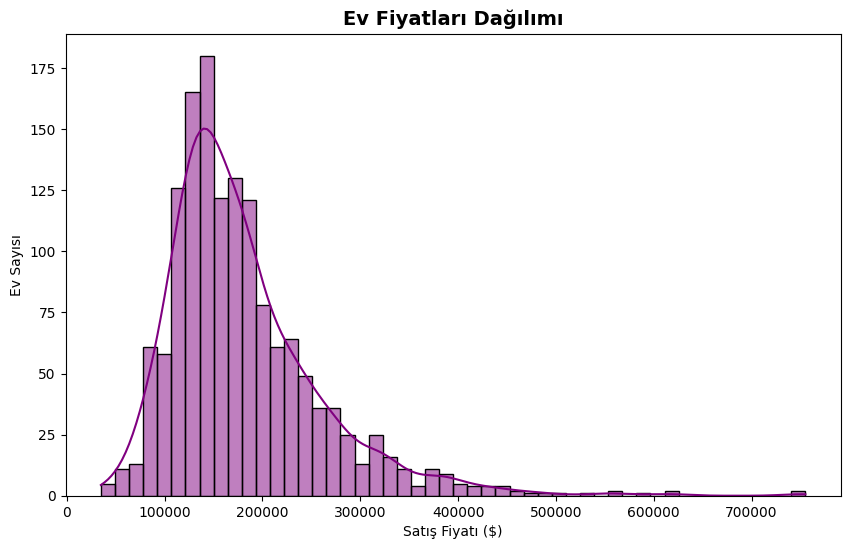


SalePrice Çarpıklık (Skewness) Değeri: 1.88


In [ ]:
plt.figure(figsize=(10, 6))

# Histogram ve Yoğunluk Grafiği (KDE)
sns.histplot(df['SalePrice'], kde=True, color='purple', bins=50)

plt.title('Ev Fiyatları Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Satış Fiyatı ($)')
plt.ylabel('Ev Sayısı')

plt.show()

# İstatistiksel kanıt
print(f"\nSalePrice Çarpıklık (Skewness) Değeri: {df['SalePrice'].skew():.2f}")

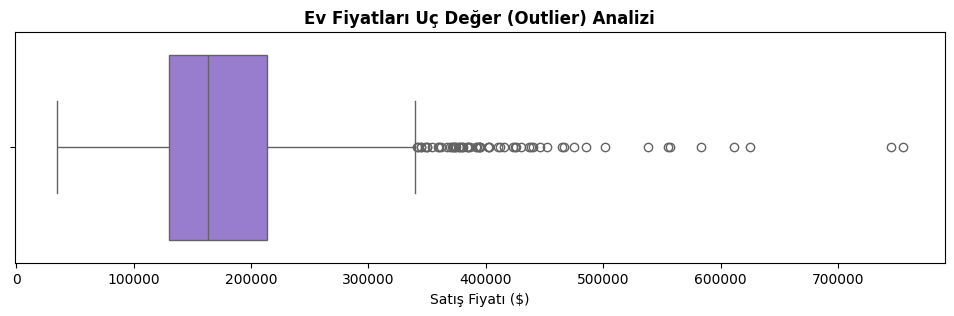

In [ ]:
# Box Plot formatında bakalım
plt.figure(figsize=(12, 3))

sns.boxplot(x=df['SalePrice'], color='mediumpurple')

plt.title('Ev Fiyatları Uç Değer (Outlier) Analizi', fontweight='bold')
plt.xlabel('Satış Fiyatı ($)')

plt.show()

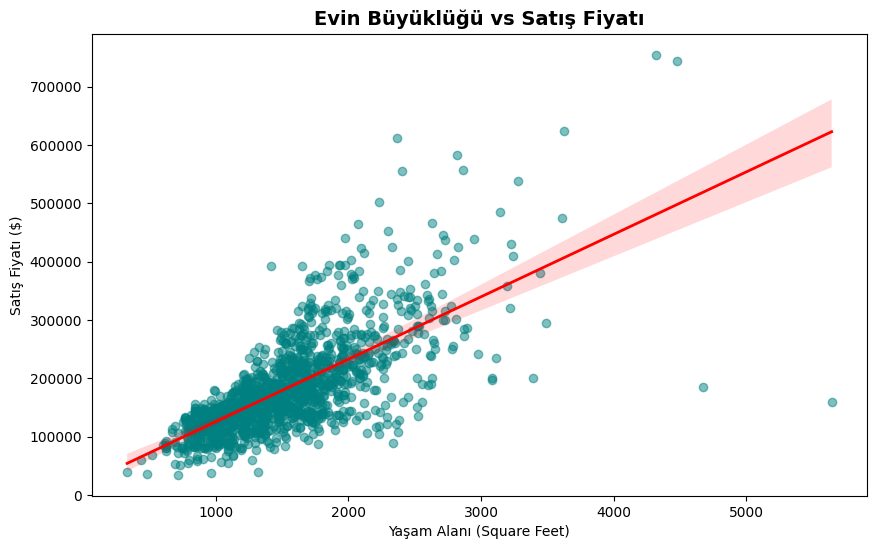

In [ ]:
plt.figure(figsize=(10, 6))

# Evin Boyutu vs Fiyatı (Scatter Plot)
# sns.regplot eğilim çizgisi için
sns.regplot(x=df['GrLivArea'], y=df['SalePrice'],
            scatter_kws={'color': 'teal', 'alpha': 0.5},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Evin Büyüklüğü vs Satış Fiyatı', fontsize=14, fontweight='bold')
plt.xlabel('Yaşam Alanı (Square Feet)')
plt.ylabel('Satış Fiyatı ($)')

plt.show()

iki evde vergi kaçırılmış heralde sağ altta iki nokta aşırı alakasız.

Aklınca bizim eğitim modelini kandıracaklar aykırı değerlerle. o yüzden onu modelin kafadan silmemiz lazım.

In [ ]:
# O iki saçma veriyi silicem daha doğru predictionlar için
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

print("Aykırı değerler (outliers) başarıyla imha edildi.")

Aykırı değerler (outliers) başarıyla imha edildi.


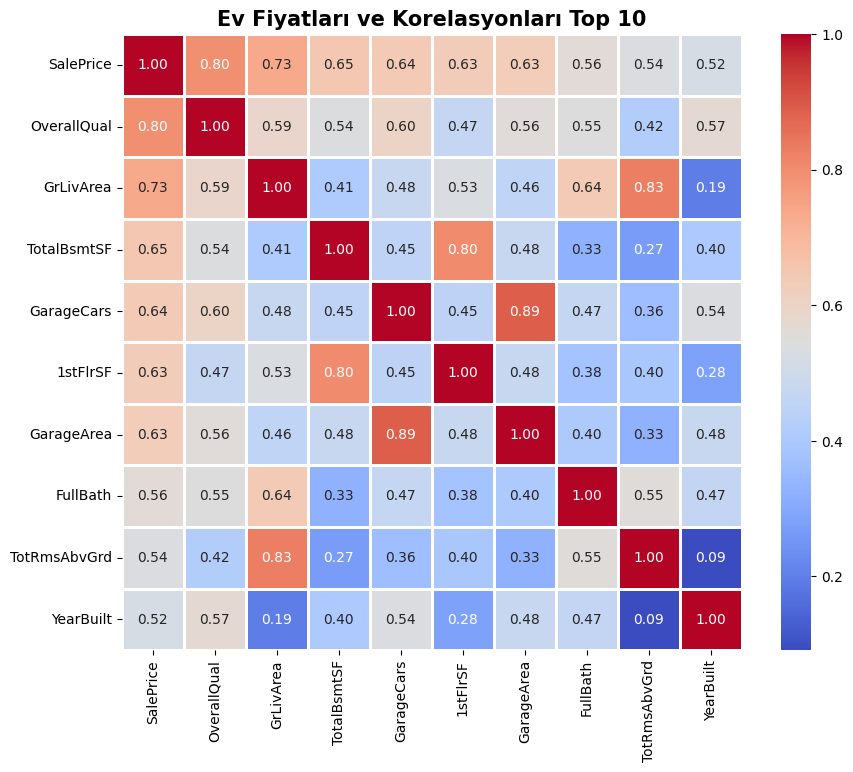

In [ ]:
# sayısal verilerle korelasyon sağlıyoruz
sayisal_df = df.select_dtypes(include=['int64', 'float64'])

# saleprice ile en yüksek korelasyona sahip 10 sütunu alalım
top_10_sutun = sayisal_df.corr().nlargest(10, 'SalePrice')['SalePrice'].index

# sadece bu 10 sütun arasında kendi korelasyonlarına bakalım.
korelasyon_matrisi = sayisal_df[top_10_sutun].corr()

# show başlıyo, heatmap çizdiriyoruz.
plt.figure(figsize=(10, 8))

# annot=True: Kutuların içine sayıları yazdırır. cmap='coolwarm': Kırmızı/Mavi renk tonu yapar
sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=2)

plt.title('Ev Fiyatları ve Korelasyonları Top 10', fontsize=15, fontweight='bold')
plt.show()

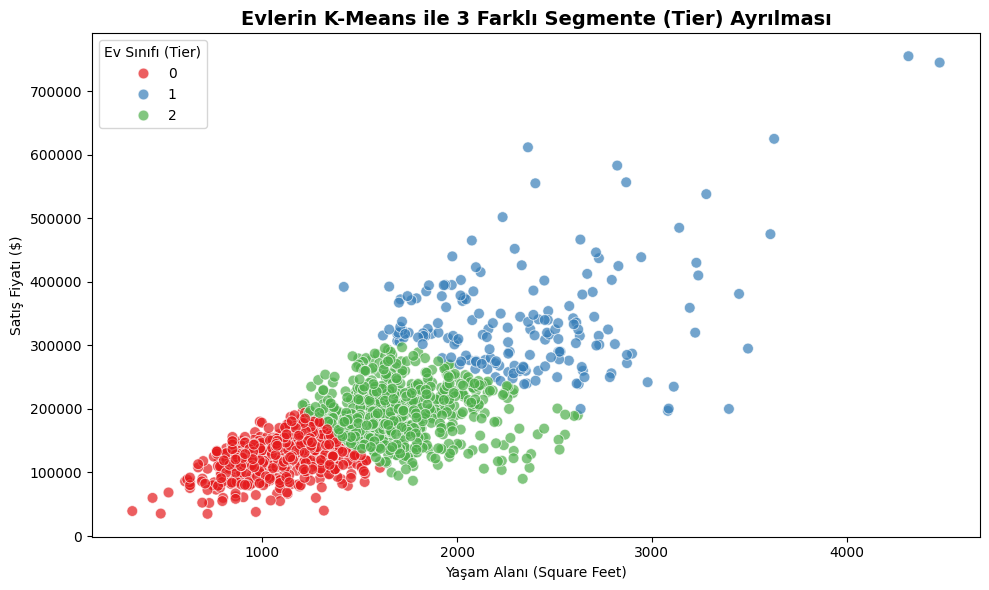

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# korelasyonu yüksek iki veriyi seçtik.
cluster_data = df[['GrLivArea', 'SalePrice']].copy()

# Fiyatlar 300.000 lerde, metrekareler 2000 lerde geziyor.
# Eğer ölçeklemezsek, fiyatın devasa sıfırları algoritmayı ezer.
# İkisini de aynı matematiksel düzleme (standart sapmaya) çekelim.
# scaling bu açıdan önemli.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# K-Means Algoritmasıyla evleri 3 farklı sınıfa ayıralım.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# modeli eğitip hangi evlere hangi sınıflar düştü öğrenelim.
cluster_data['Cluster'] = kmeans.fit_predict(scaled_data)

# veriyi görselleştirme
plt.figure(figsize=(10, 6))

# palette renk şeması, s=60 boyut için
sns.scatterplot(x='GrLivArea', y='SalePrice', hue='Cluster',
                data=cluster_data, palette='Set1', s=60, alpha=0.7)

plt.title('Evlerin K-Means ile 3 Farklı Segmente (Tier) Ayrılması', fontsize=14, fontweight='bold')
plt.xlabel('Yaşam Alanı (Square Feet)')
plt.ylabel('Satış Fiyatı ($)')
plt.legend(title='Ev Sınıfı (Tier)')

plt.tight_layout()
plt.show()

evin yaşı ile ilgili daha iyi makineye ilişki aşılamak istiyorum o yüzden kendimiz bir algoritma yapalım o tarafta:

In [ ]:
# Evin satıldığı anki yaşı
df['Evin_Yasi'] = df['YrSold'] - df['YearBuilt']
#Evin toplam kullanabilir alanı, bodrum nan olan evler hata vermesin diye fillna yaptık.
df['Toplam_Alan'] = df['TotalBsmtSF'].fillna(0) + df['GrLivArea']

print("Tanımlama tamam. Yeni özellikler tabloya eklendi.")

Tanımlama tamam. Yeni özellikler tabloya eklendi.


In [ ]:
df[['Evin_Yasi', 'Toplam_Alan', 'SalePrice']].corr()

,Evin_Yasi,Toplam_Alan,SalePrice
Evin_Yasi,1.000000,-0.342054,-0.524067
Toplam_Alan,-0.342054,1.000000,0.829042
SalePrice,-0.524067,0.829042,1.000000


🌲 Karar Ağacı R2 Skoru: 0.817
📉 Ortalama Hata (RMSE): $31,819


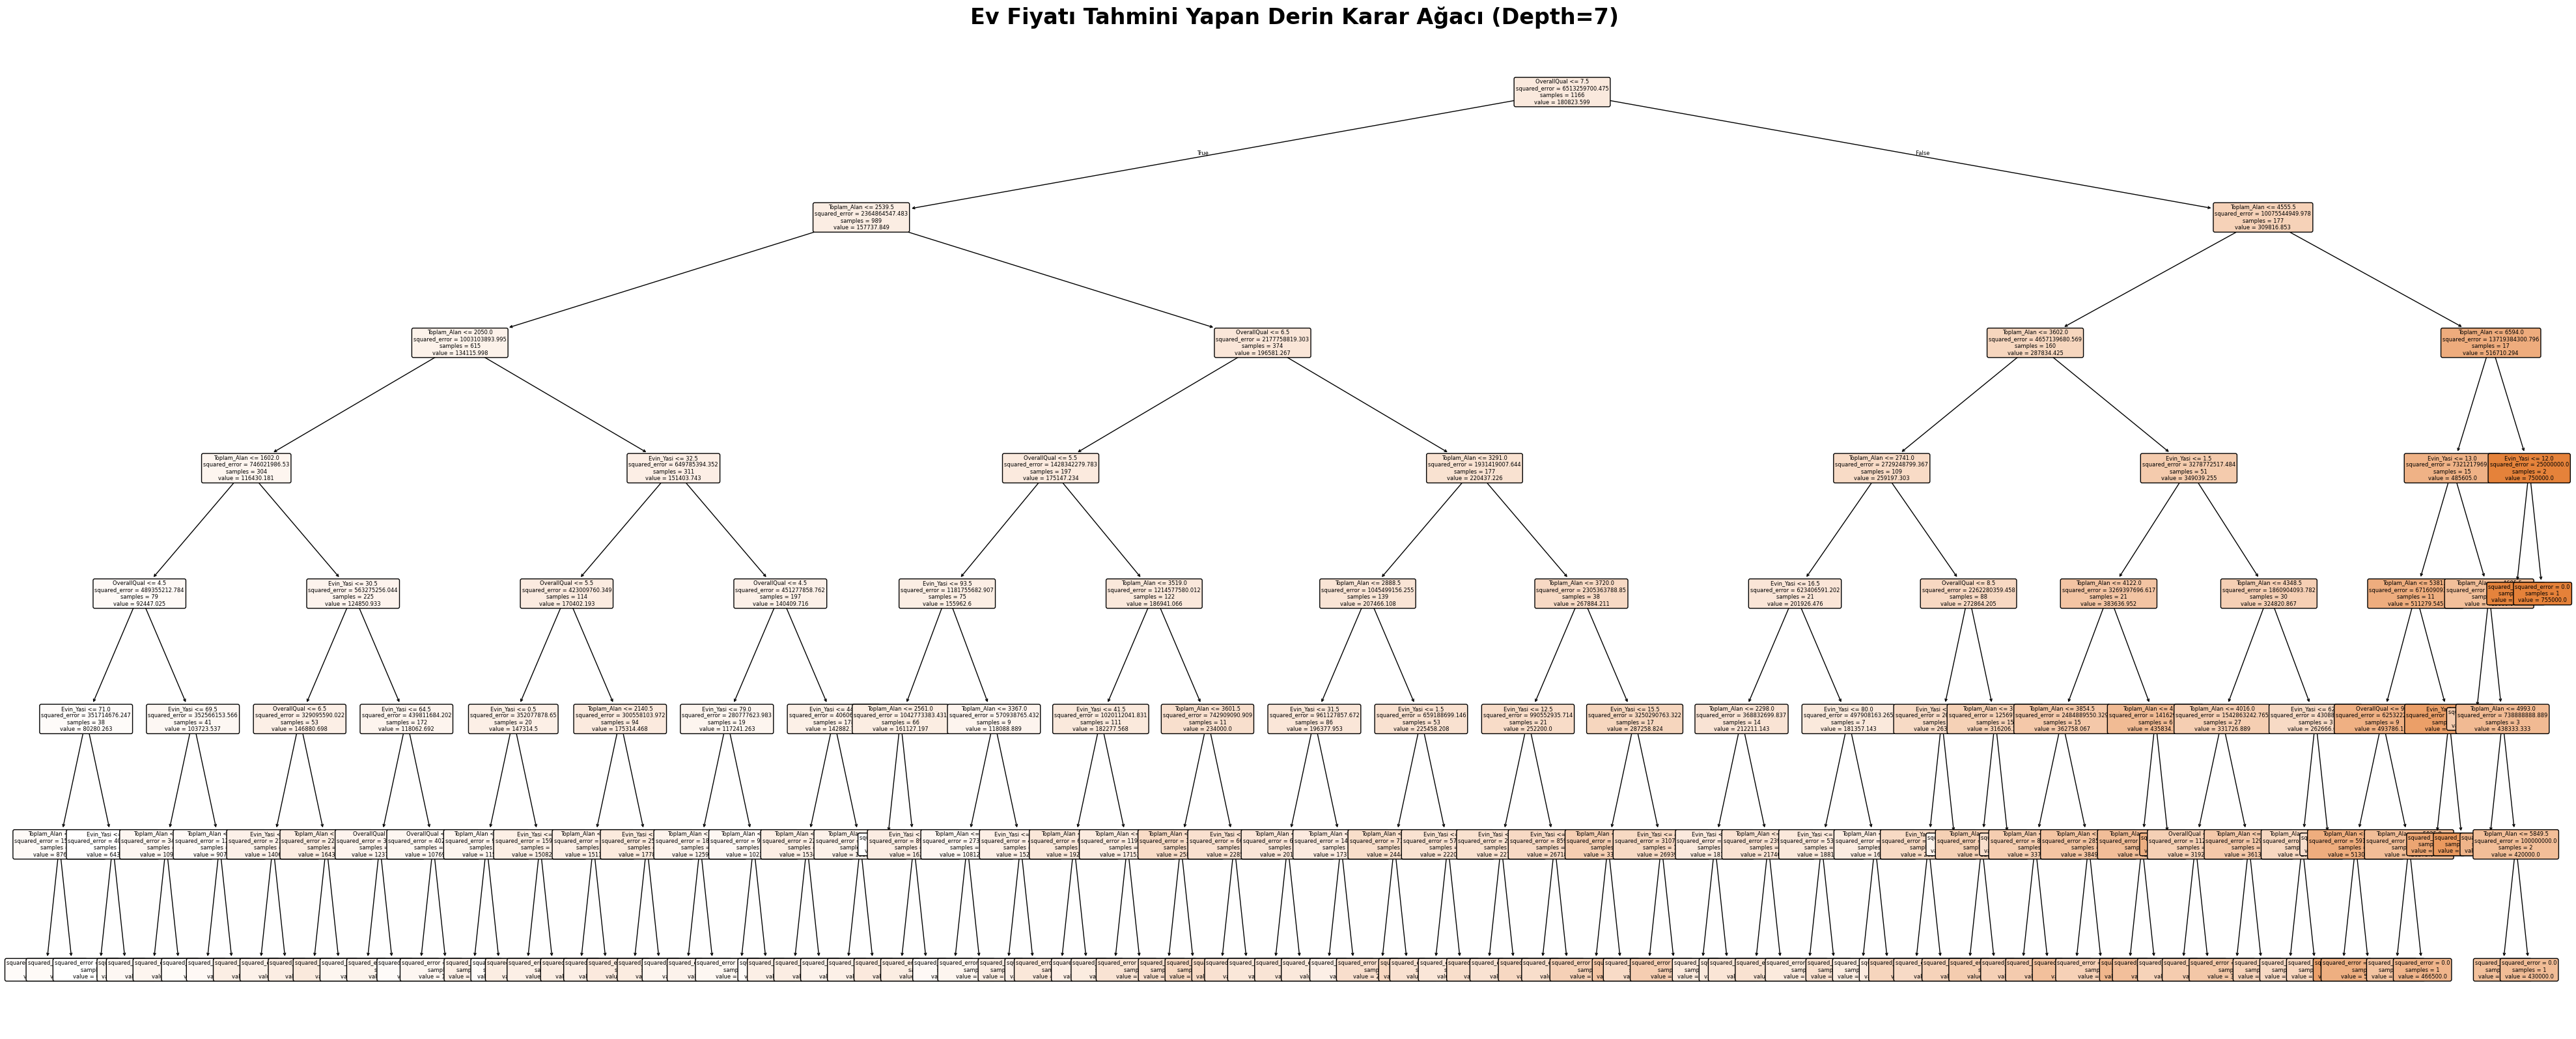

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Ürettiğimiz süper özellikler ve en güçlü korelasyonları sahaya sürüyoruz
X = df[['Toplam_Alan', 'OverallQual', 'Evin_Yasi']]
y = df['SalePrice']

# 2. Eğitim ve Test bölünmesi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# max_depth=4: Ağacın çok derine inip ezberlemesini (overfitting) engellemek için 4 soruyla sınırlandırıyoruz
tree_model = DecisionTreeRegressor(max_depth=7, random_state=42)
tree_model.fit(X_train, y_train)

# Tahmin ve Başarı Ölçümü
y_pred = tree_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"🌲 Karar Ağacı R2 Skoru: {r2:.3f}")
print(f"📉 Ortalama Hata (RMSE): ${rmse:,.0f}")

# Ağacın Kurduğu Mantığı Çizdirme
plt.figure(figsize=(50, 20))

# fontsize=6 yapıp yazıları bayağı küçültüyoruz ki kutuya sığsın
plot_tree(tree_model, feature_names=X.columns, filled=True, rounded=True, fontsize=6)

plt.title("Ev Fiyatı Tahmini Yapan Derin Karar Ağacı (Depth=7)", fontsize=24, fontweight='bold')

# Grafiği yüksek çözünürlüklü bir fotoğraf olarak kaydediyoruz (opsiyonel ama iyi olur)
# plt.savefig("derin_karar_agaci.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
#Test Verisi Deneme
test_df = pd.read_csv('test.csv')

# eski verileri craftlıyoruz.
test_df['Evin_Yasi'] = test_df['YrSold'] - test_df['YearBuilt']
test_df['Toplam_Alan'] = test_df['TotalBsmtSF'].fillna(0) + test_df['GrLivArea']

# modele vereceğimiz hedefe kilitli 3 statı seçiyoruz
X_gercek_test = test_df[['Toplam_Alan', 'OverallQual', 'Evin_Yasi']]

# boşları dolduralım
X_gercek_test = X_gercek_test.fillna(X_gercek_test.mean())

# eğittiğimiz Karar Ağacı modeline fiyatları tahmin ettiriyoruz
tahmin_edilen_fiyatlar = tree_model.predict(X_gercek_test)

# 5. Kaggle'ın İstediği Formatta Teslimat (Submission) Dosyasını Hazırlıyoruz
# Sadece Evin ID'si ve bizim Tahmin Ettiğimiz Fiyat olacak
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': tahmin_edilen_fiyatlar
})


print("Tahminler başarıyla yapıldı")
print(submission.head()) # İlk 5 tahmini yapalım

Tahminler başarıyla yapıldı
     Id      SalePrice
0  1461  127109.000000
1  1462  167074.000000
2  1463   60000.000000
3  1464  180268.985507
4  1465  177625.000000


2 modeli daha karşılaştıralım. XGBoost ve random forest.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Tek bir ağaç yerine 100 ağaçlık bir orman deneyelim.
# max_depth'i biraz daha serbest bırakabiliriz çünkü orman ezberlemeyi kendi dengeler.
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# XGBoost, Hataları sırayla düzelten model.
# Derinliği (max_depth) düşük tutuyoruz ki her adımda küçük küçük öğrensin.
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_r2 = r2_score(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

# --- KAPISMA SONUÇLARI ---
print("="*40)
print("🏆 ŞAMPİYONLAR LİGİ: EMLAK TAHMİNİ 🏆")
print("="*40)
print(f"🌱 Karar Ağacı (Senin) -> R2: 0.817 | RMSE: $31,819")
print(f"🌳 Random Forest       -> R2: {rf_r2:.3f} | RMSE: ${rf_rmse:,.0f}")
print(f"🚀 XGBoost             -> R2: {xgb_r2:.3f} | RMSE: ${xgb_rmse:,.0f}")
print("="*40)

🏆 ŞAMPİYONLAR LİGİ: EMLAK TAHMİNİ 🏆
🌱 Karar Ağacı (Senin) -> R2: 0.817 | RMSE: $31,819
🌳 Random Forest       -> R2: 0.850 | RMSE: $28,777
🚀 XGBoost             -> R2: 0.853 | RMSE: $28,483


güzel ama yeterli değil. %90 hedefleyelim.

In [ ]:
import numpy as np

# Hedef değişkenin Logaritmasını alıyoruz
y_train_log = np.log1p(y_train_p)
y_test_log = np.log1p(y_test_p)

# Modeli logaritmik fiyatlar üzerinden eğitiyoruz
xgb_log_model = xgb.XGBRegressor(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42)
xgb_log_model.fit(X_train_p, y_train_log)

#Tahmin yapıyoruz (Logaritmik)
log_pred = xgb_log_model.predict(X_test_p)

#Tahminleri gerçek Dolar değerine geri çeviriyoruz
gercek_fiyat_tahmini = np.expm1(log_pred)

# Skoru normal y_test_p (orijinal fiyatlar) ile ölçüyoruz
yeni_r2 = r2_score(y_test_p, gercek_fiyat_tahmini)
yeni_rmse = np.sqrt(mean_squared_error(y_test_p, gercek_fiyat_tahmini))

print(f"Log Dönüşümü Sonrası RMSE: ${yeni_rmse:,.0f}")
print(f"Log Dönüşümü Sonrası R2  : {yeni_r2:.4f}")

Log Dönüşümü Sonrası RMSE: $26,985
Log Dönüşümü Sonrası R2  : 0.8682


Zormuş.. Yine de iyi ilerledik ama :)